In [1]:
import logic.pulsed.pulse_objects as po
from logic.pulsed.sampling_functions import SamplingFunctions as SF
import time
import matplotlib.pyplot as plt
import pickle
import datetime
from tqdm import tqdm
from matplotlib.pyplot import cm
import numpy as np
pjl = pulsedjupyterlogic_AWG #Make sure the Logic is started in the Qudi manager!!!!

In [2]:
def setup_autoapproach():
    #configuration of autoapproach settings
    # for HFAmpl signal

    threshold = spm._dev.base.getParameter(spm._dev.base.getConst('ID_REG_SETP_DISP')) / 1e7
    spm._dev.aap.setAApThreshold(threshold)

    # dF     8
    # HFAmpl       13
    input_signal = spm._dev.base.getParameter(spm._dev.base.getConst('ID_REG_INPUT'))
    threshold_cond = 1 if input_signal==13 else 0        
    spm._dev.aap.setAApStopCondition(threshold_cond) # [0, 1] >threshold/<threshold
    spm._dev.aap.setAApStepsPerApproach(0)

    spm._dev.aap.setAApAproachMode(1) # [0, 1] Ramp/Loop
    spm._dev.aap.setAApModeAfter(0) # [0, 1, 2] On/Retract/Off

def get_pos(reps=5):
    pos = 0
    for i in range(reps):
        pos = pos+ spm.get_sample_pos()['Z']
        time.sleep(0.005)
    return pos/reps

def go_into_contact():
    spm._dev.base.setParameter(spm._dev.base.getConst('ID_AAP_CTRL'), 1, 0)
    while not spm.is_probe_landed():
        time.sleep(0.001)
    time.sleep(0.5)
        
def do_lift_off(lift_off_height):
    pos = get_pos()
    new_pos = pos - lift_off_height
    spm._dev.base.setParameter(spm._dev.base.getConst('ID_REG_LOOP_ON'), 0, 0)
    spm._dev.base.setParameter(spm._dev.base.getConst('ID_REG_SET_Z_M'), new_pos*1e12, 0)

#### Define general measurement params

In [3]:
#measurement parameters
laser_power_voltage = 0.1#podmrlogic.laser_power_voltage

#Driving information for the first LO (SMBV)
target_freq_0 = 3.114e9
LO_freq_0 = target_freq_0 + 100e6
power_0 = 0
pi_pulse = 64e-9 

#For same NV rabi SGS is run with power_1 = power_0 - 11dBm
#Driving information for the second LO (SGS)
target_freq_1 = 2.87e9
LO_freq_1 = target_freq_1 + 100e6
power_1 = -100
pi_pulse_1 = 72e-9

switch_MW = False #If True, MW1 is used as the main MW source

#additional information for save tag
tip_name = 'A-P16-24'
sample = 'CPW'
temperature = ''
b_field = ''
contact = 'OOC'
res_freq = 195e3
extra = f'{res_freq/1e3}kHz_FC_ON_AC_Off'

#### Load and ready PL Osc. sequence

100%|######################################################################################| 40/40 [03:44<00:00,  5.62s/it]


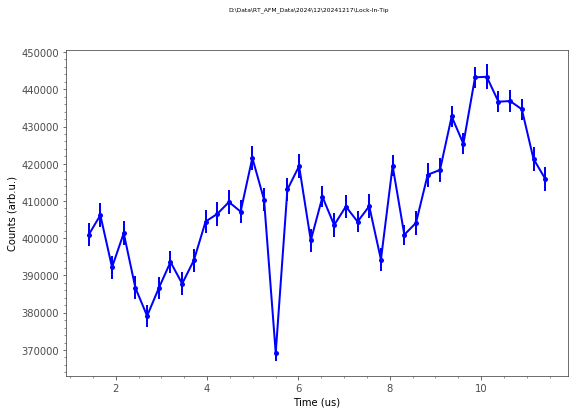

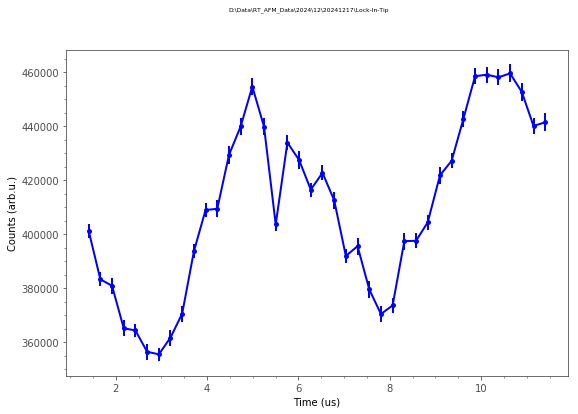

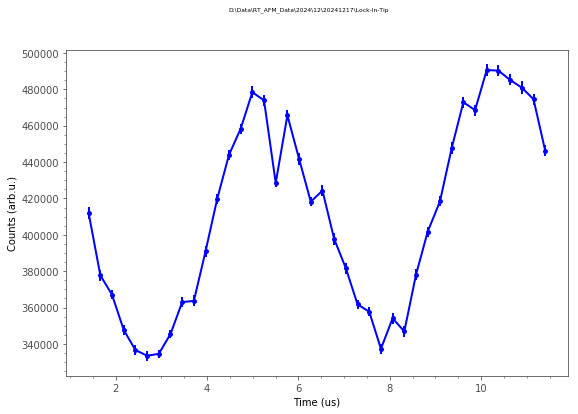

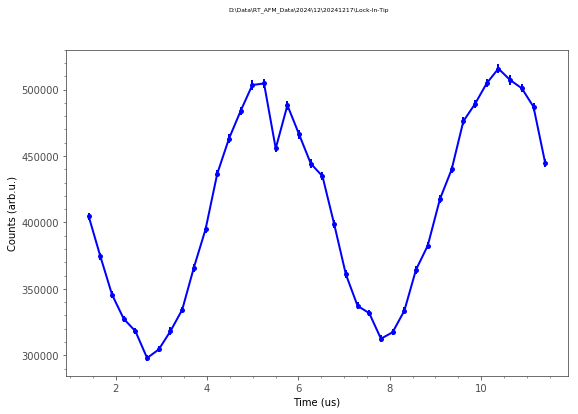

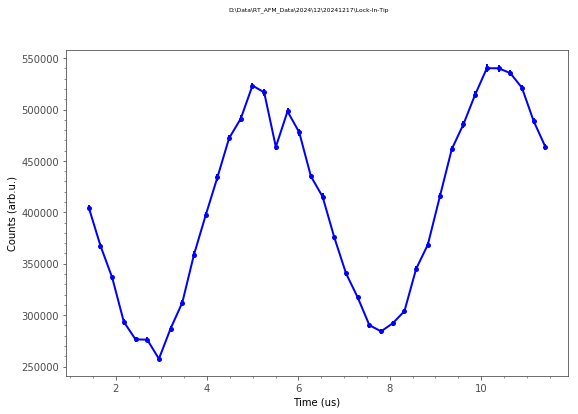

In [4]:
TF_Amp_arr = np.linspace(0.01, 0.1, 5)
# TF_Amp_arr = [0.1, 0.15, 0.2, 0.25, 0.3] #in V
HF_Ampl = 0 #in V
wait_bw_TF_set = 10

t0_start = 1e-6
t0_stop = 11e-6
t0_num = 40
max_sweeps = 200e3

alternating = False
t0_sweep_init = np.linspace(t0_start, t0_stop, t0_num)
t0_sweep = np.zeros_like(t0_sweep_init)
PL_osc = np.zeros_like(t0_sweep_init)
PL_osc_sweeps = np.zeros_like(t0_sweep_init)
PL_osc_err = np.zeros_like(t0_sweep_init)
afm_scanner_logic.jupyter_meas_stop = False

meas_dict = {}
awg_spectrum.instance.stop()
analysis_time = pulsedmeasurementlogic_AWG.analysis_settings["signal_end"] - pulsedmeasurementlogic_AWG.analysis_settings["signal_start"] 
pulsedmeasurementlogic_AWG.set_analysis_settings({"method":"sum"})

for TF_Amp in TF_Amp_arr:
    spm._dev.afm.setTFExcitationAmplitude(TF_Amp)
    time.sleep(wait_bw_TF_set)
    with tqdm(t0_sweep_init) as progress_bar:

        for i, t_0 in enumerate(progress_bar):
            pjl.initialize_ensemble(laser_power_voltage = laser_power_voltage, pi_pulse=pi_pulse, 
                                    pi_pulse_1=pi_pulse_1, LO_freq_0=LO_freq_0, target_freq_0=target_freq_0, 
                                    power_0=power_0, LO_freq_1=LO_freq_1, target_freq_1=target_freq_1, power_1=power_1, 
                                    switch_MW = switch_MW, trigger_type = 'pos_edge_rearm', trigger_level0 = 400, trigger_level1 = -200)

            ret = pjl.PL_Osc_gradiometry(t_0)
            t0_sweep[i] = ret[5]
    #         print(ret[5]/1e-6, " - Actual T_0 time used in (us)")
            pulsedmeasurementlogic_AWG._PulsedMeasurementLogic__elapsed_sweeps = 0
            pjl.start_measurement(measurement_type='PL_Osc_gradiometry', tip_name=tip_name, sample=sample, 
                                  temperature=temperature, b_field=b_field, contact=contact, extra=extra)

            while True and not afm_scanner_logic.jupyter_meas_stop:
                if pulsedmasterlogic_AWG.elapsed_sweeps>max_sweeps:
                    pulsedmeasurementlogic_AWG.stop_pulsed_measurement()
                    PL_osc[i]  = pulsedmasterlogic_AWG.signal_data[1][0]/analysis_time
                    PL_osc_err[i]  = pulsedmasterlogic_AWG.measurement_error[1][0]/analysis_time
                    PL_osc_sweeps[i]  = pulsedmasterlogic_AWG.elapsed_sweeps
                    break
                else:
                    time.sleep(0.01)

            if afm_scanner_logic.jupyter_meas_stop:
                break


    meas_dict[TF_Amp] = {"t0_sweep": t0_sweep.copy(), "PL_Osc": PL_osc.copy(), "PL_osc_err": PL_osc_err.copy(), "PL_osc_sweeps": PL_osc_sweeps.copy()}
    
    fig, ax1 = plt.subplots(1,1)
    ax1.errorbar(x=t0_sweep/1e-6, y=PL_osc/PL_osc_sweeps,
                             yerr=PL_osc_err/PL_osc_sweeps, fmt='bo-', label=f'', color="black")

    ax1.set_xlabel('Time (us)')
    ax1.set_ylabel('Counts (arb.u.)')

    filelabel = tip_name+'_'+extra
    parameters = {'Res_freq':res_freq, 'A_exc':TF_Amp, 'Hf_ampl': HF_Ampl, "Note": "test"}
    data =  {'Time (us), Counts (arb.u.), Counts_err, Elapsed_sweeps': np.array((t0_sweep, PL_osc, PL_osc_err, PL_osc_sweeps)).T}
    filepath = savelogic.get_path_for_module(module_name='Lock-In-Tip')
    fig.suptitle(filepath, fontsize=6)
    plt.show()
    savelogic.save_data(data, parameters=parameters, filepath=filepath, filelabel=filelabel, plotfig=fig, delimiter='\t')

pulsedmeasurementlogic_AWG.set_analysis_settings({"method":"mean_norm"})    

string = datetime.datetime.now().isoformat('_','seconds')+'_'+'PL_Osc_Exc_sweep'+'_'+tip_name+'_'+extra
filename = string.replace(':','-')
filepath = savelogic.get_path_for_module(module_name='Lock-In-Tip\\')

with open(filepath+filename+'.pickle', 'wb') as f:
    pickle.dump(meas_dict, f)

#### Load and ready Gradiometry sequence with lift off

  0%|                                                                                               | 0/40 [00:00<?, ?it/s]

b'Call: (SPC_TRIG_DELAY, 12512 (0x000030e0)) -> card is still running, access not possible'
b'Call: (SPC_TRIG_DELAY, 12512 (0x000030e0)) -> card is still running, access not possible'


  0%|                                                                                               | 0/40 [00:03<?, ?it/s]


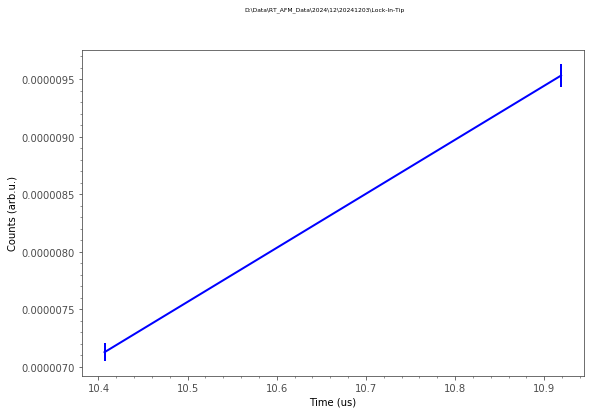

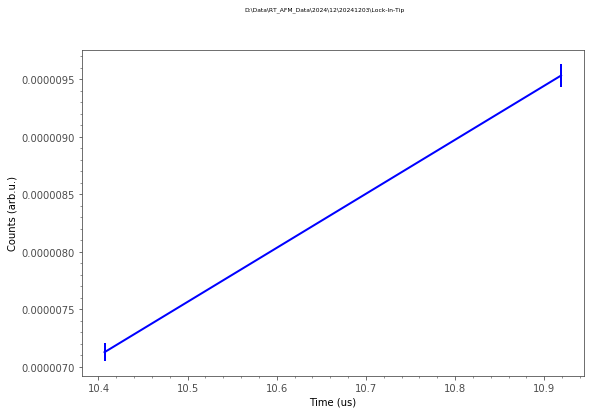

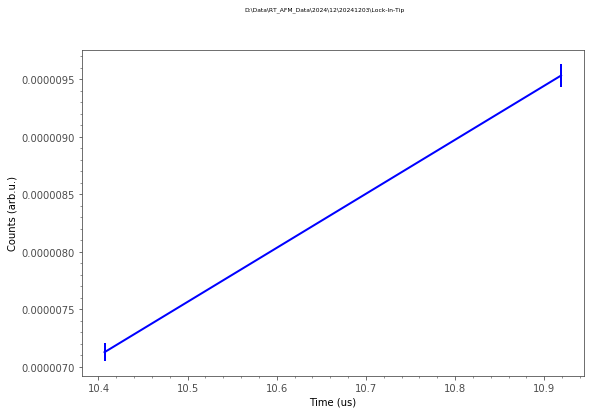

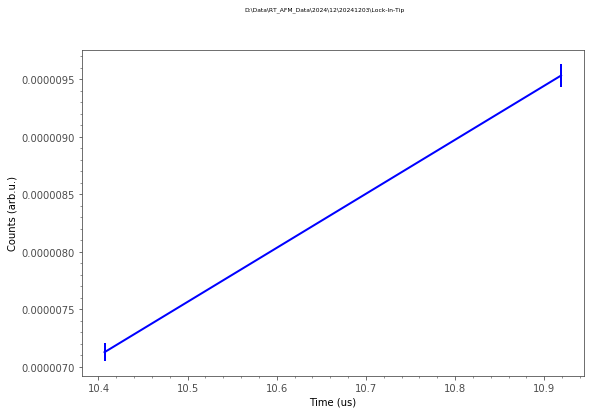

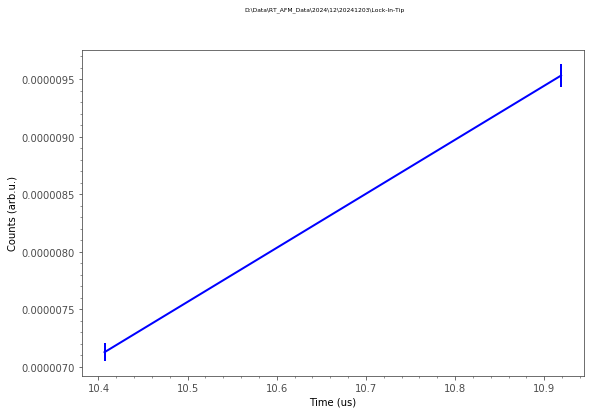

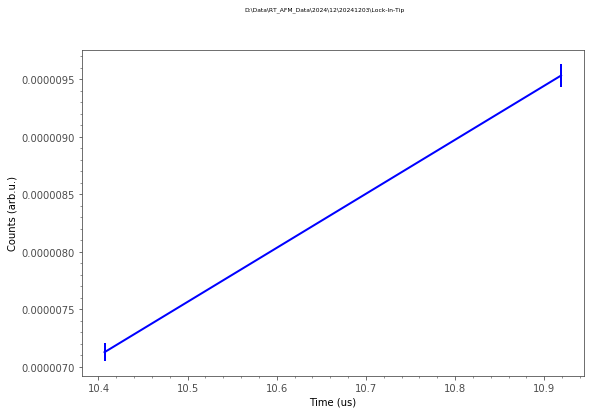

In [1]:
# TF_Amp_arr = np.linspace(2, 2, 1)
TF_Amp_arr = [4.0]
HF_Ampl = 0.205 #None

lift_off_height_list = np.linspace(10e-9, 50e-9, 6)
lift_off_check_period = 60*5

wait_bw_TF_set = 0

t0_start = 10e-6
t0_stop = 30e-6
t0_num = 40
max_sweeps = 4e5

alternating = False
t0_sweep_init = np.linspace(t0_start, t0_stop, t0_num)
t0_sweep = np.zeros_like(t0_sweep_init)
PL_osc = np.zeros_like(t0_sweep_init)
PL_osc_sweeps = np.zeros_like(t0_sweep_init)
PL_osc_err = np.zeros_like(t0_sweep_init)
afm_scanner_logic.jupyter_meas_stop = False

meas_dict = {}

setup_autoapproach()
go_into_contact()

for lift_off_height in lift_off_height_list:
#     spm._dev.afm.setTFExcitationAmplitude(TF_Amp)
#     time.sleep(wait_bw_TF_set)

    for i, t_0 in enumerate(tqdm(t0_sweep_init)):
        pjl.initialize_ensemble(laser_power_voltage = laser_power_voltage, pi_pulse=pi_pulse, 
                                pi_pulse_1=pi_pulse_1, LO_freq_0=LO_freq_0, target_freq_0=target_freq_0, 
                                power_0=power_0, LO_freq_1=LO_freq_1, target_freq_1=target_freq_1, power_1=power_1, 
                                switch_MW = switch_MW, trigger_type = 'pos_edge_rearm', trigger_level0 = 400, trigger_level1 = -200)

        ret = pjl.PL_Osc_gradiometry(t_0)
        t0_sweep[i] = ret[5]
#         print(ret[5]/1e-6, " - Actual T_0 time used in (us)")
        pulsedmeasurementlogic_AWG._PulsedMeasurementLogic__elapsed_sweeps = 0
    
        #Lift off
        lift_off_start = 0
        if lift_off_height > 0:
            do_lift_off(lift_off_height)
            lift_off_start = time.time()
            
        pjl.start_measurement(measurement_type='PL_Osc_gradiometry', tip_name=tip_name, sample=sample, 
                              temperature=temperature, b_field=b_field, contact=contact, extra=extra)

        while True and not afm_scanner_logic.jupyter_meas_stop:
            if abs(lift_off_start-time.time())>=lift_off_check_period and lift_off_height > 0 and lift_off_check_period > 0:
                pulsedmeasurementlogic_AWG.pause_pulsed_measurement()
                go_into_contact()
                do_lift_off(lift_off_height)
                lift_off_start = time.time()
                pulsedmeasurementlogic_AWG.continue_pulsed_measurement()
            
            if pulsedmasterlogic_AWG.elapsed_sweeps>max_sweeps:
                pulsedmeasurementlogic_AWG.stop_pulsed_measurement()
                PL_osc[i]  = pulsedmasterlogic_AWG.signal_data[1][0]
                PL_osc_err[i]  = pulsedmasterlogic_AWG.measurement_error[1][0]
                PL_osc_sweeps[i]  = pulsedmasterlogic_AWG.elapsed_sweeps
                break
            else:
                time.sleep(0.01)

        go_into_contact()      
        
        if afm_scanner_logic.jupyter_meas_stop:
            break


    meas_dict[lift_off_height] = {"t0_sweep": t0_sweep.copy(), "PL_Osc": PL_osc.copy(), "PL_osc_err": PL_osc_err.copy(), "PL_osc_sweeps": PL_osc_sweeps.copy()}
    
    fig, ax1 = plt.subplots(1,1)
    ax1.errorbar(x=t0_sweep/1e-6, y=PL_osc/PL_osc_sweeps,
                             yerr=PL_osc_err/PL_osc_sweeps, fmt='b-', label=f'')

    ax1.set_xlabel('Time (us)')
    ax1.set_ylabel('Counts (arb.u.)')

    filelabel = tip_name
    parameters = {'Res_freq':190e3, 'A_exc':TF_Amp, 'Hf_ampl': HF_Ampl, "Note": ""}
    data =  {'Time (us), Counts (arb.u.), Counts_err, Elapsed_sweeps': np.array((t0_sweep, PL_osc, PL_osc_err, PL_osc_sweeps)).T}
    filepath = savelogic.get_path_for_module(module_name='Lock-In-Tip')
    fig.suptitle(filepath, fontsize=6)
    plt.show()
    savelogic.save_data(data, parameters=parameters, filepath=filepath, filelabel=filelabel, plotfig=fig, delimiter='\t')

spm.retract_probe()
string = datetime.datetime.now().isoformat('_','seconds')+'_'+'PL_Osc_Exc_sweep'+'_'+tip_name
filename = string.replace(':','-')
filepath = savelogic.get_path_for_module(module_name='Lock-In-Tip\\')

with open(filepath+filename+'.pickle', 'wb') as f:
    pickle.dump(meas_dict, f)

Pickle load

In [29]:
root = r"D:\Data\RT_AFM_Data\2024\12\20241217\Lock-In-Tip"
path = root +"\\"+ "2024-12-17_17-49-08_PL_Osc_Exc_sweep_A-P16-24_195.0kHz_FC_ON_AC_Off" 
with open(path+'.pickle', 'rb') as f:
    data = pickle.load(f)

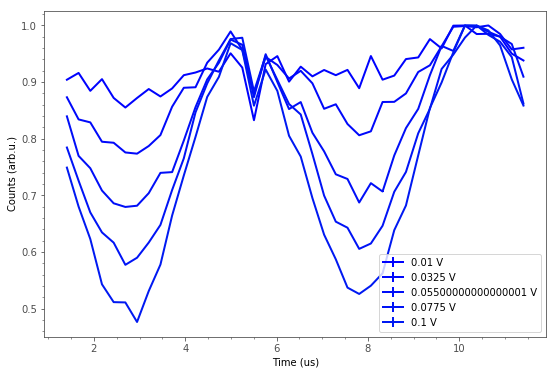

In [61]:
import matplotlib as mpl

fig, ax1 = plt.subplots(1,1)

cm = plt.get_cmap('winter')
cl = cm(list(data.keys()))

for i, key in enumerate(data.keys()):
    t0_sweep = data[key]["t0_sweep"]
    PL_osc = data[key]["PL_Osc"]
    PL_osc_sweeps = data[key]["PL_osc_sweeps"]
    PL_osc_err = data[key]["PL_osc_err"]
    c = PL_osc/PL_osc_sweeps
#     c = c - np.mean(c)
    c /= c.max()
    color = mpl.colors.rgb2hex(cl[i], keep_alpha=True)
    ax1.errorbar(x=t0_sweep/1e-6, y=c,
                             yerr=PL_osc_err/PL_osc_sweeps/PL_osc_err.max(),color=color,mec=color, 
                             label=f'{key} V')

    ax1.set_xlabel('Time (us)')
    ax1.set_ylabel('Counts (arb.u.)')
plt.legend()
plt.show()

In [50]:
PL_osc = data[0.01]["PL_Osc"]

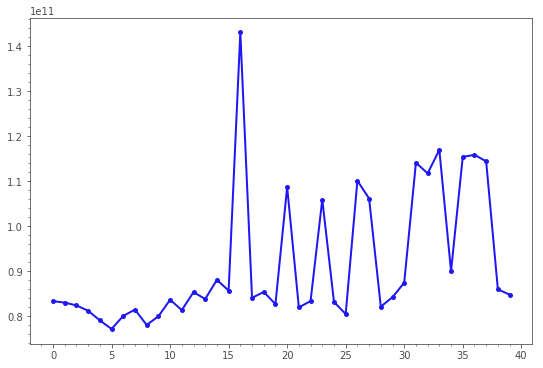

In [51]:
plt.plot(PL_osc)
plt.show()